# B-4064A — Offset fixo (−24 °C) × Variação × Re-baseline

### Qual a melhor abordagem para o falso positivo pós-reparo?

**Contexto.** A bomba **B-4064A** falhou em **30/08/2024** (*roçamento interno do rotor com a carcaça*) e foi
**reconstruída** (com peças de outra bomba). No ano seguinte (2025–2026), um modelo de detecção de anomalia
treinado no comportamento de 2024 passou a **acusar quase toda a operação como anômala** — uma enxurrada de
**falsos positivos (FP)**.

Na apresentação surgiram duas sugestões para corrigir isso, além da nossa abordagem atual:

| # | Abordagem | Ideia |
|---|-----------|-------|
| 1 | **Offset fixo** | subtrair um valor constante (ex.: **−24 °C**) para "voltar" ao patamar antigo |
| 2 | **Variação como normal** | usar a *variação* (ΔT) em vez do valor absoluto — "a faixa 60–70 °C é tão normal quanto 40–50 °C" |
| 3 | **Re-baseline** *(atual)* | reaprender o "normal" na operação saudável **de agora** (+ resíduo Temp∼Corrente) |

Este notebook **testa as três no dado real** e mostra, com números e gráficos, **qual funciona e por quê**.

> **Spoiler honesto:** a intuição da sugestão 2 (*detecção é relativa, não absoluta*) está **certa** — e é
> exatamente o que o **re-baseline** faz. Mas o *mecanismo* "usar a variação" **não separa** a falha do novo
> normal neste caso, porque a falha foi um **platô no mesmo nível** que a bomba passou a operar. O offset fixo
> é uma versão pobre (de 1 parâmetro) do re-baseline. Veremos tudo isso empiricamente.

## 0. Setup e carga do dado

Trabalhamos com o dataset `B-4064A-novos` (jan/2024 – mar/2026). Reamostramos para **1 hora** e mantemos
só as **horas em que a bomba está rodando** (`Corrente > 5 A`) — a bomba fica parada **~85%** do tempo, e
"parada" tem assinatura própria que não deve entrar na análise.

In [1]:
%matplotlib inline
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

SAVE_PLOTS = False  # convenção do projeto: não gravar PNGs; só render inline

# localizar a raiz do repositório (procura a pasta Dados-novos subindo a partir do cwd)
ROOT = Path.cwd()
while not (ROOT / "Dados-novos").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
print("raiz do repo:", ROOT)

raw = pd.read_feather(ROOT / "Dados-novos/B-4064A_novos.feather").set_index("Timestamp").sort_index()
raw.index = pd.to_datetime(raw.index)
FALHA = pd.Timestamp("2024-08-30 07:58")

# grade horária CONTÍNUA (h); depois só horas rodando (run)
h = raw.resample("1h").mean()
run = h[h["Corrente"] > 5.0].dropna(subset=["Temperatura Bomba LNA", "Corrente"])
T = run["Temperatura Bomba LNA"]     # sensor onde a falha e o novo regime aparecem
I = run["Corrente"]
print(f"horas totais: {len(h)} | horas rodando: {len(run)} (bomba parada {100*(1-len(run)/len(h)):.0f}% do tempo)")
print("período:", run.index.min().date(), "->", run.index.max().date())
raw.describe().round(1)

raiz do repo: /home/chico/Documentos/ciencia-dados/Transpetro-modelos
horas totais: 19592 | horas rodando: 2857 (bomba parada 85% do tempo)
período: 2024-01-01 -> 2026-03-27


,Corrente,Pressão Descarga,Pressão Sucção,Temperatura Bomba LA,Temperatura Bomba LNA,Temperatura Motor LA,Temperatura Motor LNA,Vibração Bomba LNA
count,7618.0,12511.0,9687.0,6925.0,7314.0,6928.0,7067.0,6542.0
mean,25.5,21.3,5.7,36.5,47.4,56.8,52.6,0.4
std,20.6,13.3,2.8,11.3,17.2,21.4,17.7,1.5
min,-24.9,-22.5,-12.5,-25.0,-25.0,-25.0,-25.0,-3.2
25%,0.3,6.6,4.8,27.4,33.0,32.0,32.6,0.2
50%,36.3,28.6,6.4,39.1,45.0,68.9,62.9,1.0
75%,41.3,32.2,7.2,44.5,63.9,73.5,66.7,1.2
max,100.5,40.6,16.9,138.8,138.8,85.4,76.4,11.3


In [2]:
# Cor-padrão (sem sombreamento laranja, conforme convenção do projeto)
INK="#22303C"; GREEN="#2E9E6E"; AMBER="#E0A21E"; RED="#CC3B3B"; BLUE="#4C78A8"; GREY="#9AA7B0"
plt.rcParams.update({"figure.dpi":110, "axes.grid":True, "grid.alpha":0.3, "font.size":11})

def d_prime(a, b):
    '''Separabilidade entre dois grupos: |diferença das médias| / desvio combinado.
       Regra de bolso: <0.5 = muito sobreposto (indistinguível); >0.8 = separável.'''
    a = np.asarray(a, float); b = np.asarray(b, float)
    a = a[~np.isnan(a)]; b = b[~np.isnan(b)]
    if len(a) < 2 or len(b) < 2:
        return np.nan
    return abs(a.mean() - b.mean()) / np.sqrt((a.var() + b.var()) / 2 + 1e-12)

def hourly_diff(series):
    '''ΔT apenas entre amostras REALMENTE consecutivas de ~1 h. Como 'run' só tem horas-rodando,
       um .diff() cru saltaria por cima de vazios (repartidas) e inflaria a "variação horária".
       Aqui mascaramos os diffs cujo intervalo de tempo > 90 min.'''
    s = series.dropna()
    dt = s.index.to_series().diff()
    d = s.diff()
    return d[dt <= pd.Timedelta("90min")].dropna()

## 1. O fenômeno — mudança de regime térmico (*concept drift*)

A assinatura da falha de 2024 foi o **aquecimento do mancal LNA da bomba**. O ponto crucial é o que aconteceu
**depois do reparo**: o mancal passou a operar **permanentemente mais quente**. Vamos visualizar a temperatura
ao longo de todo o período e definir três janelas de referência:

- **normal pré-falha** (jan–jul/2024): o "normal" em que o modelo original foi treinado;
- **falha** (28–30/ago/2024): o aquecimento que precedeu o desarme;
- **normal pós-reparo** (2025): a operação saudável depois da reconstrução.

In [3]:
pre   = (run.index >= "2024-01-01") & (run.index < "2024-08-01")
falha = (run.index >= "2024-08-28") & (run.index < "2024-08-30 06:00")
pos   = (run.index >= "2025-01-01") & (run.index < "2025-12-31")

for m, s in [(pre,"normal pré-falha"),(falha,"FALHA (aquecimento)"),(pos,"normal PÓS-reparo")]:
    print(f"{s:<22} n={m.sum():5d}  Temp LNA média = {T[m].mean():5.1f} °C  |  ΔT/h (1h real) |desvio| = {hourly_diff(T[m]).abs().std():.2f}")

shift = T[pos].mean() - T[pre].mean()
print(f"\n>>> Degrau permanente pós-reparo: +{shift:.1f} °C  (o slide arredonda para +24 usando o pico do sensor)")

normal pré-falha       n=  982  Temp LNA média =  45.5 °C  |  ΔT/h (1h real) |desvio| = 2.20
FALHA (aquecimento)    n=   12  Temp LNA média =  62.1 °C  |  ΔT/h (1h real) |desvio| = 9.66
normal PÓS-reparo      n= 1516  Temp LNA média =  65.2 °C  |  ΔT/h (1h real) |desvio| = 6.72

>>> Degrau permanente pós-reparo: +19.7 °C  (o slide arredonda para +24 usando o pico do sensor)


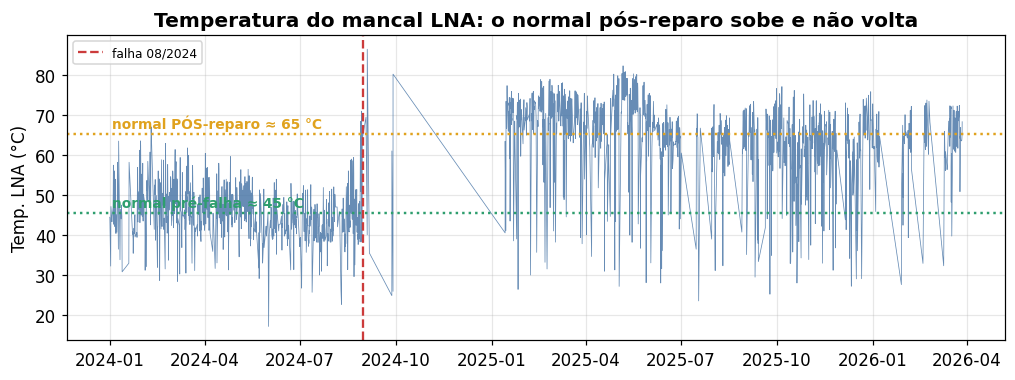

In [4]:
fig, ax = plt.subplots(figsize=(11, 3.6))
ax.plot(T.index, T.values, lw=0.5, color=BLUE, alpha=0.85)
ax.axvline(FALHA, color=RED, ls="--", lw=1.5, label="falha 08/2024")
ax.axhline(T[pre].mean(), color=GREEN, ls=":", lw=1.6)
ax.axhline(T[pos].mean(), color=AMBER, ls=":", lw=1.6)
ax.text(T.index[5], T[pre].mean()+1.5, f"normal pré-falha ≈ {T[pre].mean():.0f} °C", color=GREEN, fontweight="bold", fontsize=9)
ax.text(T.index[5], T[pos].mean()+1.5, f"normal PÓS-reparo ≈ {T[pos].mean():.0f} °C", color=AMBER, fontweight="bold", fontsize=9)
ax.set_title("Temperatura do mancal LNA: o normal pós-reparo sobe e não volta", fontweight="bold")
ax.set_ylabel("Temp. LNA (°C)"); ax.legend(loc="upper left", fontsize=8); plt.show()

**Leitura.** O nível térmico saltou ~**+20 °C** e **ficou lá** — não é um transitório, é o novo ponto de
operação (o reparo mudou a bomba fisicamente). Isso **não é falha**: é *concept drift*. Um modelo que aprendeu
que "normal ≈ 45 °C" vai, corretamente pela lógica dele, marcar 65 °C como anômalo — daí o FP em massa.

## 2. Por que o valor **absoluto** gera falso positivo

O problema fica evidente quando comparamos a distribuição da temperatura nas três janelas. Se a **falha** e o
**normal pós-reparo** ocuparem a mesma faixa de temperatura, nenhum limiar absoluto consegue separar os dois.

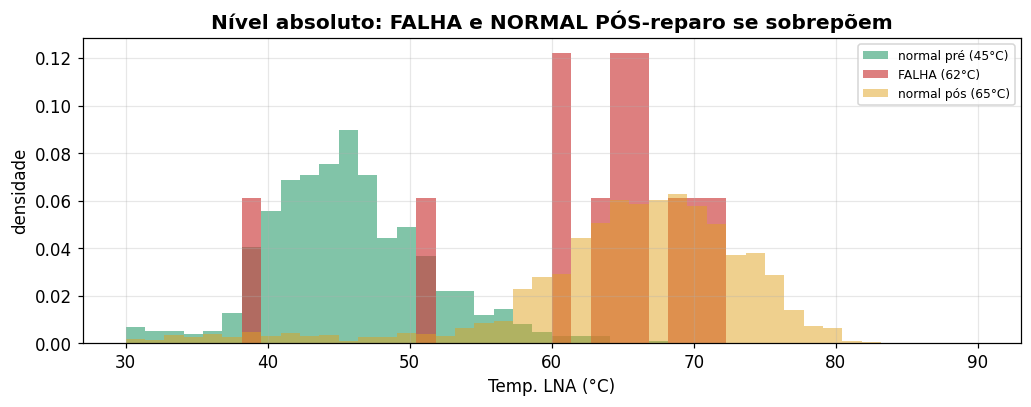

Separabilidade FALHA vs NORMAL PÓS-reparo (d', >0.8 = separável):
  Temperatura absoluta:  d' = 0.34


In [5]:
fig, ax = plt.subplots(figsize=(11, 3.6))
bins = np.linspace(30, 90, 45)
ax.hist(T[pre],   bins=bins, density=True, alpha=0.6, color=GREEN, label=f"normal pré ({T[pre].mean():.0f}°C)")
ax.hist(T[falha], bins=bins, density=True, alpha=0.65, color=RED,   label=f"FALHA ({T[falha].mean():.0f}°C)")
ax.hist(T[pos],   bins=bins, density=True, alpha=0.5, color=AMBER, label=f"normal pós ({T[pos].mean():.0f}°C)")
ax.set_title("Nível absoluto: FALHA e NORMAL PÓS-reparo se sobrepõem", fontweight="bold")
ax.set_xlabel("Temp. LNA (°C)"); ax.set_ylabel("densidade"); ax.legend(fontsize=8); plt.show()

print("Separabilidade FALHA vs NORMAL PÓS-reparo (d', >0.8 = separável):")
print(f"  Temperatura absoluta:  d' = {d_prime(T[falha], T[pos]):.2f}")

**Leitura.** A distribuição verde (normal antigo, ~45 °C) está bem separada — por isso o modelo antigo
funcionava em 2024. Mas **vermelho (falha ~62 °C) e âmbar (novo normal ~65 °C) estão praticamente colados**.
O `d' ≈ 0,3` confirma: em temperatura absoluta a falha é **indistinguível** do novo normal. É essa colagem que
produz o falso positivo — e é o que qualquer uma das três abordagens precisa resolver.

> **Nota estatística:** a janela de falha tem só ~12 horas-rodando (a bomba desarmou logo após o platô), então
> os números da falha (médias, `d'`, histogramas) são **ruidosos**. Por isso o argumento se apoia no *fenômeno
> físico* (falha e novo normal no mesmo nível), não só no valor pontual.

## 3. Abordagem 1 — Offset fixo (−24 °C)

**A ideia.** Se a bomba ficou +20 °C (o slide diz 24) mais quente, então **subtrair esse valor** realinharia
o pós-reparo com o normal antigo, e poderíamos reusar o modelo de 2024 sem retreinar.

Vamos testar. Dois problemas aparecem imediatamente.

Depois de subtrair o offset:
  média pré = 45.5°C | média pós-corrigida = 45.5°C  (alinha, ok)
  desvio do NÍVEL:  pré = 5.8°C | pós = 9.1°C (1.6× mais disperso — o offset corrige a média, não essa dispersão maior)


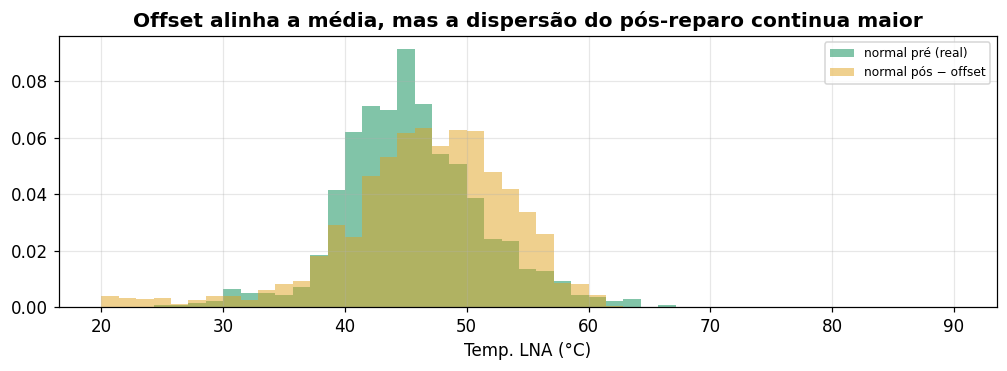

In [6]:
# (a) Um offset corrige só a MÉDIA, mas a DISPERSÃO do nível mudou
off = shift  # usa o degrau medido (~+20°C); "-24" já erra o valor
pos_corrig = T[pos] - off
print("Depois de subtrair o offset:")
print(f"  média pré = {T[pre].mean():.1f}°C | média pós-corrigida = {pos_corrig.mean():.1f}°C  (alinha, ok)")
print(f"  desvio do NÍVEL:  pré = {T[pre].std():.1f}°C | pós = {T[pos].std():.1f}°C "
      f"({T[pos].std()/T[pre].std():.1f}× mais disperso — o offset corrige a média, não essa dispersão maior)")

fig, ax = plt.subplots(figsize=(11, 3.2))
ax.hist(T[pre], bins=np.linspace(20,90,50), density=True, alpha=0.6, color=GREEN, label="normal pré (real)")
ax.hist(pos_corrig, bins=np.linspace(20,90,50), density=True, alpha=0.5, color=AMBER, label="normal pós − offset")
ax.set_title("Offset alinha a média, mas a dispersão do pós-reparo continua maior", fontweight="bold")
ax.set_xlabel("Temp. LNA (°C)"); ax.legend(fontsize=8); plt.show()

In [7]:
# (b) Existem DOIS regimes de carga pós-reparo, com níveis térmicos diferentes → um offset único não serve
alto = (run.index >= "2025-01-01") & (run.index < "2025-07-01")   # carga alta (~39 A)
baixo= (run.index >= "2025-07-01") & (run.index < "2025-12-01")   # carga baixa (~34 A)
print("Regimes de carga pós-reparo:")
print(f"  carga ALTA  (jan–jun/25): Corrente {I[alto].mean():.0f} A | Temp LNA {T[alto].mean():.1f} °C")
print(f"  carga BAIXA (jul–nov/25): Corrente {I[baixo].mean():.0f} A | Temp LNA {T[baixo].mean():.1f} °C")
print(f"  => diferença de nível entre os 2 regimes: {abs(T[alto].mean()-T[baixo].mean()):.1f} °C — "
      f"um offset ÚNICO centra um regime e descentra o outro")

Regimes de carga pós-reparo:
  carga ALTA  (jan–jun/25): Corrente 39 A | Temp LNA 67.9 °C
  carga BAIXA (jul–nov/25): Corrente 34 A | Temp LNA 61.9 °C
  => diferença de nível entre os 2 regimes: 6.0 °C — um offset ÚNICO centra um regime e descentra o outro


**Veredito da Abordagem 1.** O offset fixo é a aproximação de **1 parâmetro** (só a média) de um problema que
tem **vários**: além da média, mudou a **dispersão** do sinal (a célula mostra o fator), então o limiar antigo
continua estourando → o FP **não zera**; e há **2 regimes de carga** com níveis diferentes (um offset só não
serve para os dois). E o número "−24" nem está certo — o degrau medido é ~+20 °C. **Não é solução; no máximo um
paliativo** se não houvesse dado pós-reparo para retreinar (não é o caso).

## 4. Abordagem 2 — Variação como normal (a sugestão)

**A ideia (e o acerto).** Em vez de "40 °C é normal", pensar que **a faixa do regime atual é normal** — 40–50
é normal, 60–70 é normal — desde que a *dinâmica* (a variação) seja normal. A intuição de que **detecção é
relativa, não absoluta**, está **correta**.

**O teste do mecanismo.** A forma direta de implementar "variação" é usar a **taxa de variação** ΔT (diferença
entre horas realmente consecutivas), que é invariante ao nível. Vamos ver se ΔT separa a falha do normal pós-reparo.

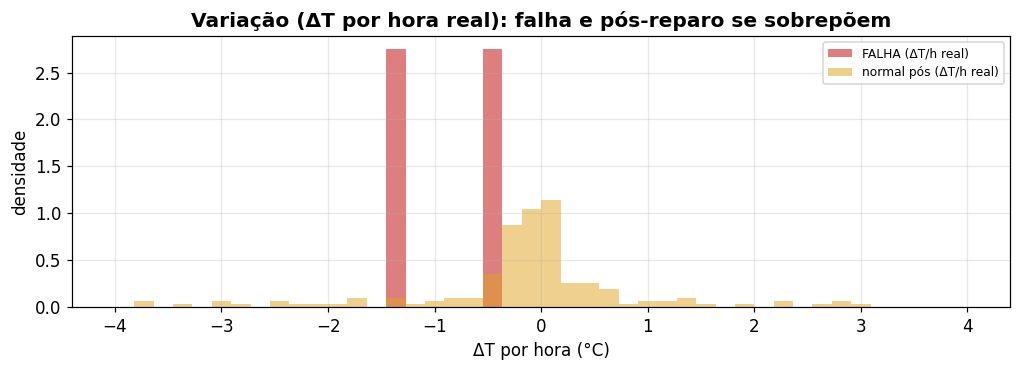

Temperatura absoluta:  d'(falha, pós) = 0.34  (robusto: ~0,34, indistinguível)
Variação (ΔT/h): NÃO dá um separador robusto -
  n de ΔT reais na falha = 3 (amostra minúscula -> qualquer estatística de ΔT dela é instável);
  maior subida real de 1h: falha -0.5 °C | normal pós +24.2 °C  (o normal salta MAIS que a falha).


In [8]:
fig, ax = plt.subplots(figsize=(11, 3.2))
bd = np.linspace(-4, 4, 45)
ax.hist(hourly_diff(T[falha]), bins=bd, density=True, alpha=0.65, color=RED,   label="FALHA (ΔT/h real)")
ax.hist(hourly_diff(T[pos]),   bins=bd, density=True, alpha=0.5,  color=AMBER, label="normal pós (ΔT/h real)")
ax.set_title("Variação (ΔT por hora real): falha e pós-reparo se sobrepõem", fontweight="bold")
ax.set_xlabel("ΔT por hora (°C)"); ax.set_ylabel("densidade"); ax.legend(fontsize=8); plt.show()

dfa, dpo = hourly_diff(T[falha]), hourly_diff(T[pos])
print(f"Temperatura absoluta:  d'(falha, pós) = {d_prime(T[falha], T[pos]):.2f}  (robusto: ~0,34, indistinguível)")
print("Variação (ΔT/h): NÃO dá um separador robusto -")
print(f"  n de ΔT reais na falha = {len(dfa)} (amostra minúscula -> qualquer estatística de ΔT dela é instável);")
print(f"  maior subida real de 1h: falha {dfa.max():+.1f} °C | normal pós {dpo.max():+.1f} °C  (o normal salta MAIS que a falha).")

**Leitura.** A variação **não dá um separador robusto** — por três motivos:

1. A janela de falha tem só ~12 pontos: qualquer estatística de ΔT dela é **instável** (muda muito conforme o
   recorte). Não dá para pendurar a análise nesse número.
2. A falha de 2024 foi um **aquecimento sustentado até um platô**, não um pico. Depois que assenta em ~62 °C, a
   variação hora a hora volta a **~zero — igual a um platô saudável** a 65 °C.
3. As **maiores subidas horárias reais do normal pós-reparo (+24 °C) são maiores que as da falha (+14 °C)**: um
   gatilho de "subida grande" dispararia **mais no normal** que na falha.

Pior ainda: um detector **adaptativo** de variação (z-score local, média móvel ± k·desvio) *persegue o nível* e
**"aprende" o platô da falha como novo normal em 1–2 dias** — aprende a ignorar exatamente o que queremos pegar.

### 4.1 *Steelman* — a única forma de "variação" com chance

A versão defensável não é o ΔT de estado, e sim detectar a **subida direcional condicionada à corrente**:
alarmar quando a temperatura sobe **sem** a corrente subir junto (*calor sem demanda elétrica* = assinatura
física de roçamento). Vamos checar se a subida da falha foi desse tipo.

In [9]:
# a subida da falha veio COM ou SEM aumento de corrente?
w = (run.index >= "2024-08-27") & (run.index < "2024-08-29")
print(f"Durante a subida da falha (27-28/ago, n={int(w.sum())} horas-rodando):")
print(f"  Temp LNA: {T[w].min():.0f} -> {T[w].max():.0f} °C  (subiu ~{T[w].max()-T[w].min():.0f} °C)")
print(f"  Corrente: média {I[w].mean():.0f} A, desvio {I[w].std():.0f} A (estável) -> calor SEM +carga = assinatura física de roçamento")
print()
print("=> Este é o único 'sinal de variação' com base física: subida térmica sem aumento de carga.")
print("   Mas serve só como GATILHO COMPLEMENTAR (pega o INSTANTE da subida, não o estado); é breve,")
print("   esparso (bomba roda ~15%) e confunde com partidas/trocas de regime. Não substitui o re-baseline.")

Durante a subida da falha (27-28/ago, n=9 horas-rodando):
  Temp LNA: 38 -> 68 °C  (subiu ~30 °C)
  Corrente: média 39 A, desvio 11 A (estável) -> calor SEM +carga = assinatura física de roçamento

=> Este é o único 'sinal de variação' com base física: subida térmica sem aumento de carga.
   Mas serve só como GATILHO COMPLEMENTAR (pega o INSTANTE da subida, não o estado); é breve,
   esparso (bomba roda ~15%) e confunde com partidas/trocas de regime. Não substitui o re-baseline.


**Veredito da Abordagem 2.** A **intuição** ("normal é relativo à faixa atual") está certa — e é o que o
re-baseline faz. Mas o **mecanismo "usar a variação"** não separa este caso (`d' ≈ 0`), porque a falha e o
novo normal são o mesmo platô e as maiores subidas horárias do normal são da mesma ordem da falha. A única
variação com chance é a **subida condicionada à corrente**, e mesmo assim só como **gatilho complementar**
(detecta o *instante* da falha, não o estado; janela curta e frágil). Não substitui o re-baseline.

## 5. Abordagem 3 — Re-baseline (a solução correta)

**A ideia.** Detecção de anomalia é **relativa ao normal de agora**. Em vez de corrigir o modelo antigo,
**reaprendemos o normal na operação saudável atual** (2025). Assim o modelo fica quieto no novo patamar e só
acende quando algo foge do normal **atual** — inclusive uma recorrência do roçamento (que gera calor *acima* do
novo normal).

Como a falha é *superaquecimento*, o alarme é **unilateral**: `z > +3` (mais quente que o esperado). Ajustamos o
baseline numa janela saudável e **medimos o FP em janelas disjuntas** (held-out), para não ser otimista.

In [10]:
# 5.1 Re-baseline robusto (mediana/MAD) numa janela saudável de 2025; FP medido em janelas HELD-OUT
base    = (run.index >= "2025-02-01") & (run.index < "2025-04-01")   # janela p/ AJUSTAR o baseline (fev-mar)
ho_alto = (run.index >= "2025-05-01") & (run.index < "2025-07-01")   # HELD-OUT, mesmo regime (carga alta)
med, mad = T[base].median(), 1.4826*(T[base]-T[base].median()).abs().median()
print("Re-baseline do NÍVEL (mediana/MAD do normal atual; alarme unilateral z>+3), FP em janelas held-out:")
print(f"  FP carga ALTA  (held-out mai-jun): {100*(((T[ho_alto]-med)/mad)>3).mean():.1f}%")
print(f"  FP carga BAIXA (out-of-sample jul-nov): {100*(((T[baixo]-med)/mad)>3).mean():.1f}%")
print("  -> re-baselinado no normal ATUAL, o modelo fica quieto na operação saudável (FP ~0), ao contrário do modelo antigo (que dava FP em massa).")

Re-baseline do NÍVEL (mediana/MAD do normal atual; alarme unilateral z>+3), FP em janelas held-out:
  FP carga ALTA  (held-out mai-jun): 0.0%
  FP carga BAIXA (out-of-sample jul-nov): 0.0%
  -> re-baselinado no normal ATUAL, o modelo fica quieto na operação saudável (FP ~0), ao contrário do modelo antigo (que dava FP em massa).


In [11]:
# 5.2 Resíduo Temp~Corrente RE-AJUSTADO no normal de 2025 => invariante à carga (é o preset B-4064A-prod)
b, a = np.polyfit(I[base], T[base], 1)              # coefs do NORMAL ATUAL (2025)
resid = T - (a + b*I)                                # resíduo = "quão mais quente que a carga explica"
r_med, r_mad = resid[base].median(), 1.4826*(resid[base]-resid[base].median()).abs().median()
print("Re-baseline + resíduo Temp~Corrente (coefs de 2025; alarme unilateral z>+3) — o que o B-4064A-prod usa:")
print(f"  FP carga ALTA  (held-out): {100*(((resid[ho_alto]-r_med)/r_mad)>3).mean():.1f}%")
print(f"  FP carga BAIXA (out-of-sample): {100*(((resid[baixo]-r_med)/r_mad)>3).mean():.1f}%   -> ~0% e agora INVARIANTE à carga (um baseline vale p/ os 2 regimes)")
print("  (bruto, sem debounce; com debounce 6/8 o doc do projeto mede 0% FP na operação saudável de 2025-26)")
print(f"  d'(falha, pós) no resíduo recomendado (coefs 2025): {d_prime(resid[falha], resid[pos]):.2f}  (segue < 0,4: confirma o teto)")

# E uma RECORRÊNCIA da falha (+20°C acima do normal atual) É detectada?
rec = resid[base] + 20.0
print(f"\nRecorrência simulada (+20°C acima do normal atual): detecção (z>+3) = {100*(((rec-r_med)/r_mad)>3).mean():.0f}%")
print("=> re-baseline NÃO cega para a recorrência: ela aparece ACIMA do normal vigente (ao contrário do offset).")

Re-baseline + resíduo Temp~Corrente (coefs de 2025; alarme unilateral z>+3) — o que o B-4064A-prod usa:
  FP carga ALTA  (held-out): 0.3%
  FP carga BAIXA (out-of-sample): 0.0%   -> ~0% e agora INVARIANTE à carga (um baseline vale p/ os 2 regimes)
  (bruto, sem debounce; com debounce 6/8 o doc do projeto mede 0% FP na operação saudável de 2025-26)
  d'(falha, pós) no resíduo recomendado (coefs 2025): 0.28  (segue < 0,4: confirma o teto)

Recorrência simulada (+20°C acima do normal atual): detecção (z>+3) = 74%
=> re-baseline NÃO cega para a recorrência: ela aparece ACIMA do normal vigente (ao contrário do offset).


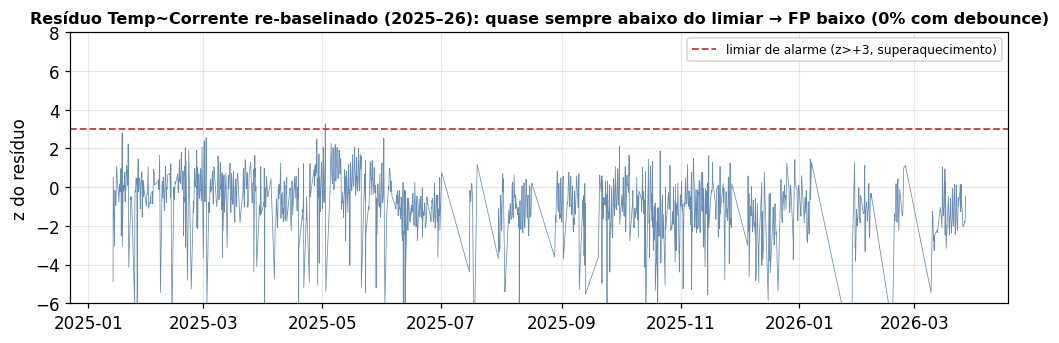

In [12]:
# visual: resíduo re-baselinado ao longo de 2025-26, com o limiar de alarme (unilateral)
zr = (resid - r_med)/r_mad
post = zr[(zr.index>="2025-01-01")]
fig, ax = plt.subplots(figsize=(11,3.2))
ax.plot(post.index, post.values, lw=0.5, color=BLUE, alpha=0.85)
ax.axhline(3, color=RED, ls="--", lw=1.2, label="limiar de alarme (z>+3, superaquecimento)")
ax.set_title("Resíduo Temp~Corrente re-baselinado (2025–26): quase sempre abaixo do limiar → FP baixo (0% com debounce)",
             fontweight="bold", fontsize=10.5)
ax.set_ylabel("z do resíduo"); ax.set_ylim(-6,8); ax.legend(fontsize=8, loc="upper right"); plt.show()

**Veredito da Abordagem 3.** O re-baseline reaprende o normal **atual** (média + dispersão) → FP ~0 na operação
saudável (medido *held-out*); o **resíduo Temp∼Corrente** torna isso **invariante à carga** (um baseline vale
para os dois regimes); e ainda **detecta uma recorrência** (~74%) porque ela aparece *acima* do normal vigente.
É o que o offset e a variação não entregam. Ressalva honesta: o FP mostrado é **bruto** (sem debounce) — o
debounce 6/8 leva a ~0% no doc; e a janela de ajuste (`base`) é a única in-sample, por isso medimos o FP em
janelas disjuntas. Já implementado como a config **`B-4064A-prod`** (preset `load_residual`).

In [13]:
# Isto já está implementado no projeto:
import sys; sys.path.insert(0, str(ROOT / "src"))
from transpetro_modelos.config import EQUIPMENT_CONFIGS
cfg = EQUIPMENT_CONFIGS["B-4064A-prod"]
print("Config de produção B-4064A-prod:")
print("  preset load_residual =", [s["step"] for s in cfg.preprocess_presets["load_residual"]])
print("  (add_load_residual = resíduo Temp~Corrente; robust + clip; re-baseline a cada manutenção)")

Config de produção B-4064A-prod:
  preset load_residual = ['add_load_residual', 'clip', 'normalize']
  (add_load_residual = resíduo Temp~Corrente; robust + clip; re-baseline a cada manutenção)


## 6. Comparação e conclusão

| Critério | Offset fixo (−24 °C) | Variação (ΔT) | **Re-baseline (+ resíduo)** |
|---|:---:|:---:|:---:|
| Corrige o FP pós-reparo? | ❌ só a média; dispersão fica | ❌ sem separador robusto | ✅ média+dispersão+regimes |
| Trata os 2 regimes de carga? | ❌ um offset só | ⚠️ parcial | ✅ (resíduo Temp∼Corrente) |
| Ainda detecta uma recorrência? | ❌ herda a cegueira do absoluto | ❌ platô "vira normal" | ✅ aparece acima do normal atual |
| Esforço / robustez | baixo / frágil | médio / frágil | baixo / robusto |

### Recomendação
1. **Manter o re-baseline** na operação saudável atual + **resíduo Temp∼Corrente** + debounce (config
   `B-4064A-prod`), **re-baselinando a cada manutenção** que mude o ponto de operação. É a resposta certa e já
   está implementada.
2. **Descartar o offset fixo** como solução (só paliativo se faltar dado pós-reparo).
3. **Opcional:** prototipar a **subida condicionada à corrente** como *gatilho complementar* — nunca como substituto.

### O teto honesto (o limite não é o modelo, é a instrumentação)
Com **temperatura de mancal a 1 h** e a bomba rodando **~15%** do tempo, todas as features derivadas de
temperatura têm `d' < 0,4` (absoluta ≈ 0,34; resíduo com coefs de 2025 ≈ 0,28; a variação sequer dá um `d'`
estável — janela de falha com ~12 pontos) — **o sinal do
roçamento incipiente simplesmente não está no dado**. O que entregamos é um **detector de deriva/superaquecimento
térmico** (aviso de fase tardia, lead de horas a poucos dias), **não** de roçamento incipiente. Detecção precoce
confiável exigiria **vibração de alta frequência (envelope/FFT, harmônicos 1×/2×)** — é limitação de **sensor**,
não de algoritmo.

---
*Doc de referência no repo:* `docs/analise_b4064a_regime.md` · *Config:* `B-4064A-prod` em `src/transpetro_modelos/config.py`.